ML Workflow:
1. Problem statement definition - classify borrowers on high risk or low risk (classification problem) (interpretability matters most)
2. Data Collection (according to the problem statement) (kaggle, open repositories, sba website, data.gov)
3. Data Cleaning/Preprocessing 
4. Model Development (Logistic regression, decision trees, random forest, xgboost, gradientboosting) (baseline model - logistic regression)
5. Model Evaluation (classification metrics- accuracy, precision, recall, f1 score, auc-roc curve)
6. Model Deployment 
7. Model Monitor & Maintenance


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns  

In [3]:
df1=pd.read_csv(r"C:\Users\aksha\OneDrive\Documents\Credit-Risk-Analysis\Dataset\foia-7a-fy2010-fy2019-as-of-251231.csv")

C:\Users\aksha\AppData\Local\Temp\ipykernel_6256\484649022.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df1=pd.read_csv(r"C:\Users\aksha\OneDrive\Documents\Credit-Risk-Analysis\Dataset\foia-7a-fy2010-fy2019-as-of-251231.csv")


In [4]:
df2 = pd.read_csv(r"C:\Users\aksha\OneDrive\Documents\Credit-Risk-Analysis\Dataset\foia-7a-fy2020-present-as-of-251231.csv")

In [5]:
df = pd.concat([df1,df2],ignore_index=True)

In [6]:
df.shape

(903617, 43)

Columns => Features/fields/attributes -> 43
Rows => Records/values/datapoints -> 9 lakhs

In [7]:
df.sample(2)

,asofdate,program,l2locid,borrname,borrstreet,borrcity,borrstate,borrzip,bankname,bankfdicnumber,...,businesstype,businessage,loanstatus,paidinfulldate,chargeoffdate,grosschargeoffamount,revolverstatus,jobssupported,collateralind,soldsecmrktind
322692,12/31/2025,7A,44449.0,L H Mercantile LLC,2103 OLD BROCK RD,WEATHERFORD,TX,76087,"PNC Bank, National Association",6384.0,...,CORPORATION,NaN,PIF,9/30/2021,NaN,0.0,1,1.0,N,NaN
853926,12/31/2025,7A,111901.0,JOJO'S SCOTTSDALE LLC,15037 N. SCOTTSDALE RD,SCOTTSDALE,AZ,85254,"LendingClub Bank, National Association",32551.0,...,CORPORATION,"Startup, Loan Funds will Open Business",EXEMPT,NaN,NaN,0.0,0,160.0,N,NaN


asofdate is str it should be datetime
bankzip is str it should be int64
approvaldate  is str it should datetime 
all date to datetim

In [8]:
df['sbaguaranteedapproval']

0         1406250.0
1           19350.0
2           25000.0
3            5000.0
4          189000.0
            ...    
903612      22500.0
903613     375000.0
903614     198000.0
903615     125475.0
903616     486180.0
Name: sbaguaranteedapproval, Length: 903617, dtype: float64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 903617 entries, 0 to 903616
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   asofdate                    903617 non-null  object 
 1   program                     903617 non-null  object 
 2   l2locid                     902614 non-null  float64
 3   borrname                    903585 non-null  object 
 4   borrstreet                  903617 non-null  object 
 5   borrcity                    903617 non-null  object 
 6   borrstate                   903617 non-null  object 
 7   borrzip                     903617 non-null  int64  
 8   bankname                    903617 non-null  object 
 9   bankfdicnumber              826650 non-null  float64
 10  bankncuanumber              27320 non-null   float64
 11  bankstreet                  902614 non-null  object 
 12  bankcity                    902614 non-null  object 
 13  bankstate     

In [10]:
df['asofdate'] = pd.to_datetime(df['asofdate'], errors='coerce')

In [11]:
df['asofdate'].dtype

dtype('<M8[ns]')

In [12]:
#target variable is loanstatus 
df['loanstatus'].value_counts()

loanstatus
PIF       445821
EXEMPT    287327
CANCLD    109174
CHGOFF     38283
COMMIT     23012
Name: count, dtype: int64

In [13]:
filt = df['loanstatus'].isin(['CHGOFF','PIF'])

In [14]:
filt.value_counts()

loanstatus
True     484104
False    419513
Name: count, dtype: int64

In [15]:
df = df.loc[filt]

In [16]:
df['loanstatus'].value_counts()

loanstatus
PIF       445821
CHGOFF     38283
Name: count, dtype: int64

In [17]:
df.shape

(484104, 43)

In [18]:
df['approvaldate'] = pd.to_datetime(df['approvaldate'], errors='coerce')
df['paidinfulldate'] = pd.to_datetime(df['paidinfulldate'], errors='coerce')
df['chargeoffdate'] = pd.to_datetime(df['chargeoffdate'], errors='coerce')
df['firstdisbursementdate'] = pd.to_datetime(df['firstdisbursementdate'], errors='coerce')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 484104 entries, 0 to 903616
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   asofdate                    484104 non-null  datetime64[ns]
 1   program                     484104 non-null  object        
 2   l2locid                     483568 non-null  float64       
 3   borrname                    484088 non-null  object        
 4   borrstreet                  484104 non-null  object        
 5   borrcity                    484104 non-null  object        
 6   borrstate                   484104 non-null  object        
 7   borrzip                     484104 non-null  int64         
 8   bankname                    484104 non-null  object        
 9   bankfdicnumber              448556 non-null  float64       
 10  bankncuanumber              16078 non-null   float64       
 11  bankstreet                  483568 non-null 

In [20]:
df.describe()

,asofdate,l2locid,borrzip,bankfdicnumber,bankncuanumber,grossapproval,sbaguaranteedapproval,approvaldate,approvalfiscalyear,firstdisbursementdate,initialinterestrate,terminmonths,naicscode,congressionaldistrict,paidinfulldate,chargeoffdate,grosschargeoffamount,revolverstatus,jobssupported
count,484104,483568.000000,484104.000000,448556.000000,16078.000000,4.841040e+05,4.841040e+05,484104,484104.000000,483588,484104.000000,484104.000000,484102.000000,484079.000000,445821,38269,4.841040e+05,484104.000000,484104.000000
mean,2025-12-31 00:00:00,100045.500544,52317.177402,17116.970780,42150.996517,3.629164e+05,2.704631e+05,2015-08-06 21:24:21.167022080,2015.339369,2015-10-02 07:50:25.951015680,6.594021,114.915429,519921.272515,9.277184,2020-04-02 01:53:15.782163200,2020-06-02 08:27:45.431550464,1.196364e+04,0.325457,10.631920
min,2025-12-31 00:00:00,20.000000,601.000000,35.000000,28.000000,1.000000e+03,5.000000e+02,2009-10-01 00:00:00,2010.000000,2009-10-01 00:00:00,0.000000,0.000000,111110.000000,0.000000,2009-11-01 00:00:00,2010-06-15 00:00:00,0.000000e+00,0.000000,0.000000
25%,2025-12-31 00:00:00,33181.000000,28164.000000,3890.000000,24312.000000,3.530000e+04,2.000000e+04,2012-09-26 00:00:00,2012.000000,2012-12-01 00:00:00,5.500000,75.000000,424480.000000,2.000000,2017-08-31 00:00:00,2017-10-03 00:00:00,0.000000e+00,0.000000,2.000000
50%,2025-12-31 00:00:00,53803.000000,51106.000000,9366.000000,60337.000000,1.050000e+05,7.500000e+04,2015-07-07 00:00:00,2015.000000,2015-09-01 00:00:00,6.000000,84.000000,531390.000000,5.000000,2020-09-30 00:00:00,2020-09-25 00:00:00,0.000000e+00,0.000000,4.000000
75%,2025-12-31 00:00:00,95589.000000,80226.000000,26397.000000,67190.000000,3.500000e+05,2.602500e+05,2018-01-04 00:00:00,2018.000000,2018-03-31 00:00:00,7.500000,120.000000,624410.000000,11.000000,2023-01-31 00:00:00,2023-07-12 00:00:00,0.000000e+00,1.000000,11.000000
max,2025-12-31 00:00:00,606942.000000,99929.000000,91280.000000,97107.000000,5.000000e+06,4.500000e+06,2025-11-19 00:00:00,2026.000000,2025-11-25 00:00:00,16.500000,420.000000,928120.000000,53.000000,2025-11-30 00:00:00,2025-12-31 00:00:00,4.706181e+06,1.000000,2150.000000
std,NaN,124996.412365,30661.959597,17781.264361,26112.281297,6.749358e+05,5.243113e+05,NaN,3.464424,NaN,1.700983,75.442064,175697.093043,10.596903,NaN,NaN,9.241278e+04,0.468546,20.527981


we can remove bankncuanumber, naicscode, congressionaldistrict,
convert terminmonths to years,

In [21]:
df=df.drop(columns=['bankncuanumber','naicscode','congressionaldistrict'])

In [22]:
df.shape

(484104, 40)

In [23]:
df['terminyears']=df['terminmonths']/12

In [24]:
df.columns

Index(['asofdate', 'program', 'l2locid', 'borrname', 'borrstreet', 'borrcity',
       'borrstate', 'borrzip', 'bankname', 'bankfdicnumber', 'bankstreet',
       'bankcity', 'bankstate', 'bankzip', 'grossapproval',
       'sbaguaranteedapproval', 'approvaldate', 'approvalfiscalyear',
       'firstdisbursementdate', 'processingmethod', 'subprogram',
       'initialinterestrate', 'fixedorvariableinterestind', 'terminmonths',
       'naicsdescription', 'franchisecode', 'franchisename', 'projectcounty',
       'projectstate', 'sbadistrictoffice', 'businesstype', 'businessage',
       'loanstatus', 'paidinfulldate', 'chargeoffdate', 'grosschargeoffamount',
       'revolverstatus', 'jobssupported', 'collateralind', 'soldsecmrktind',
       'terminyears'],
      dtype='object')

In [25]:
df['terminyears']

0         25.000000
1          7.000000
2          7.000000
3          7.000000
4          2.583333
            ...    
903604     5.000000
903607     7.000000
903612     6.000000
903615    10.000000
903616    25.000000
Name: terminyears, Length: 484104, dtype: float64

In [26]:
# borrstreet, borrcity,bankstreet, bankcity, naicsdescription, franchisecode,franchisename, soldsecmrktind
df=df.drop(columns=['borrstreet','borrcity','bankstreet','bankcity','naicsdescription','franchisecode','franchisename','soldsecmrktind'])

In [27]:
df.shape

(484104, 33)

Find duplicates

In [28]:
duplicates = df[df.duplicated(keep=False)]
duplicates

,asofdate,program,l2locid,borrname,borrstate,borrzip,bankname,bankfdicnumber,bankstate,bankzip,...,businesstype,businessage,loanstatus,paidinfulldate,chargeoffdate,grosschargeoffamount,revolverstatus,jobssupported,collateralind,terminyears
234,2025-12-31,7A,73109.0,The Alaric Company,VA,23824,Citizens Bank and Trust Company,823.0,VA,23824.0,...,CORPORATION,NaN,PIF,2012-11-30,NaT,0.0,0,12.0,Y,7.0
743,2025-12-31,7A,73109.0,The Alaric Company,VA,23824,Citizens Bank and Trust Company,823.0,VA,23824.0,...,CORPORATION,NaN,PIF,2012-11-30,NaT,0.0,0,12.0,Y,7.0
1040,2025-12-31,7A,59698.0,BBS PARTNERS INC,CA,93644,Columbia Bank,17266.0,OR,97035.0,...,CORPORATION,NaN,PIF,2022-09-30,NaT,0.0,0,9.0,Y,25.0
1063,2025-12-31,7A,59698.0,BBS PARTNERS INC,CA,93644,Columbia Bank,17266.0,OR,97035.0,...,CORPORATION,NaN,PIF,2022-09-30,NaT,0.0,0,9.0,Y,25.0
1929,2025-12-31,7A,57328.0,A 1 American LLC,OH,44107,The Huntington National Bank,6560.0,OH,43215.0,...,CORPORATION,NaN,PIF,2020-11-30,NaT,0.0,0,1.0,N,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872462,2025-12-31,7A,57328.0,Lufi Transport llc,MI,48038,The Huntington National Bank,6560.0,OH,43215.0,...,CORPORATION,Existing or more than 2 years old,PIF,2021-11-30,NaT,0.0,0,2.0,N,5.0
875619,2025-12-31,7A,57328.0,Legacy Labor Inc..,MI,49651,The Huntington National Bank,6560.0,OH,43215.0,...,CORPORATION,"Startup, Loan Funds will Open Business",PIF,2020-05-31,NaT,0.0,0,1.0,N,7.0
875686,2025-12-31,7A,57328.0,Legacy Labor Inc..,MI,49651,The Huntington National Bank,6560.0,OH,43215.0,...,CORPORATION,"Startup, Loan Funds will Open Business",PIF,2020-05-31,NaT,0.0,0,1.0,N,7.0
895345,2025-12-31,7A,33377.0,SURVEYS & ANALYSIS INC,MA,1545,UniBank for Savings,90290.0,MA,1588.0,...,CORPORATION,Existing or more than 2 years old,PIF,2025-02-28,NaT,0.0,0,6.0,Y,5.0


In [29]:
df.drop_duplicates(keep='first', inplace=True)

In [30]:
df.shape

(483737, 33)

In [31]:
df.duplicated().sum()

np.int64(0)

Count of null values in each column and how to handle them

In [32]:
df.isnull().sum()

asofdate                           0
program                            0
l2locid                          536
borrname                          16
borrstate                          0
borrzip                            0
bankname                           0
bankfdicnumber                 35540
bankstate                        536
bankzip                          536
grossapproval                      0
sbaguaranteedapproval              0
approvaldate                       0
approvalfiscalyear                 0
firstdisbursementdate            516
processingmethod                   0
subprogram                         0
initialinterestrate                0
fixedorvariableinterestind         0
terminmonths                       0
projectcounty                      0
projectstate                       0
sbadistrictoffice                  0
businesstype                       0
businessage                   352045
loanstatus                         0
paidinfulldate                 38283
c

In [33]:
#drop these columns also paidinfulldate and chargeoffdate and bankfdicnumber and borrname
df=df.drop(columns=['borrname'])

In [34]:
df.shape

(483737, 32)

In [35]:
df.drop(columns=['paidinfulldate','chargeoffdate','bankfdicnumber'], inplace=True)

In [36]:
df.isnull().sum()

asofdate                           0
program                            0
l2locid                          536
borrstate                          0
borrzip                            0
bankname                           0
bankstate                        536
bankzip                          536
grossapproval                      0
sbaguaranteedapproval              0
approvaldate                       0
approvalfiscalyear                 0
firstdisbursementdate            516
processingmethod                   0
subprogram                         0
initialinterestrate                0
fixedorvariableinterestind         0
terminmonths                       0
projectcounty                      0
projectstate                       0
sbadistrictoffice                  0
businesstype                       0
businessage                   352045
loanstatus                         0
grosschargeoffamount               0
revolverstatus                     0
jobssupported                      0
c

In [37]:
df.dropna(subset=['collateralind','l2locid','firstdisbursementdate','bankstate','bankzip'], inplace=True)

In [38]:
df.shape

(482682, 29)

In [39]:
df['businessage'].value_counts()

businessage
Existing or more than 2 years old         65375
Startup, Loan Funds will Open Business    20295
Unanswered                                14909
Change of Ownership                       11956
New Business or 2 years or less           10095
Existing, 5 or more years                  4960
New, Less than 1 Year old                  1685
Less than 3 years old but at least 2        861
Less than 4 years old but at least 3        702
Less than 5 years old but at least 4        593
Name: count, dtype: int64

In [40]:
df['businessage'] = df['businessage'].fillna('Unanswered')

In [41]:
df['businessage'].value_counts()

businessage
Unanswered                                366160
Existing or more than 2 years old          65375
Startup, Loan Funds will Open Business     20295
Change of Ownership                        11956
New Business or 2 years or less            10095
Existing, 5 or more years                   4960
New, Less than 1 Year old                   1685
Less than 3 years old but at least 2         861
Less than 4 years old but at least 3         702
Less than 5 years old but at least 4         593
Name: count, dtype: int64

In [42]:
df['businessage'] = df['businessage'].replace({'Unanswered':'Unknown'})

In [43]:
df['businessage'].value_counts()

businessage
Unknown                                   366160
Existing or more than 2 years old          65375
Startup, Loan Funds will Open Business     20295
Change of Ownership                        11956
New Business or 2 years or less            10095
Existing, 5 or more years                   4960
New, Less than 1 Year old                   1685
Less than 3 years old but at least 2         861
Less than 4 years old but at least 3         702
Less than 5 years old but at least 4         593
Name: count, dtype: int64

In [44]:
df['businesstype'].value_counts()

businesstype
CORPORATION    423661
INDIVIDUAL      50608
PARTNERSHIP      8390
                   23
Name: count, dtype: int64

In [590]:
df.shape

(482682, 29)

check the skewness in the data
if skewed handle it using transformation methods.

In [591]:
df.columns

Index(['asofdate', 'program', 'l2locid', 'borrstate', 'borrzip', 'bankname',
       'bankstate', 'bankzip', 'grossapproval', 'sbaguaranteedapproval',
       'approvaldate', 'approvalfiscalyear', 'firstdisbursementdate',
       'processingmethod', 'subprogram', 'initialinterestrate',
       'fixedorvariableinterestind', 'terminmonths', 'projectcounty',
       'projectstate', 'sbadistrictoffice', 'businesstype', 'businessage',
       'loanstatus', 'grosschargeoffamount', 'revolverstatus', 'jobssupported',
       'collateralind', 'terminyears'],
      dtype='str')

In [592]:
temp_df = df.select_dtypes(include=['number'])
skewness = temp_df.skew()


In [593]:
skewness

l2locid                   2.150565
borrzip                  -0.085549
grossapproval             3.720059
sbaguaranteedapproval     3.727654
approvalfiscalyear        0.291341
initialinterestrate       1.038900
terminmonths              1.511465
grosschargeoffamount     18.616447
revolverstatus            0.745933
jobssupported             8.534760
terminyears               1.511465
dtype: float64

In [594]:
cols = [
    'grosschargeoffamount',
    'jobssupported',
    'grossapproval',
    'sbaguaranteedapproval'
]

df[cols] = df[cols].apply(lambda x: np.log1p(x))

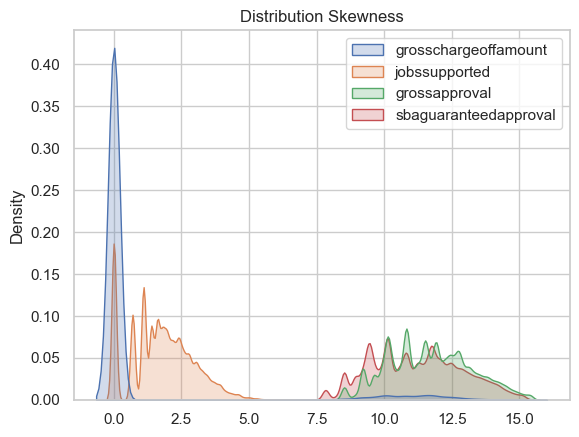

In [595]:
sns.kdeplot(df[cols], fill=True)
plt.title('Distribution Skewness')
plt.show()

In [596]:
df.info()

<class 'pandas.DataFrame'>
Index: 482682 entries, 0 to 903616
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   asofdate                    482682 non-null  datetime64[us]
 1   program                     482682 non-null  str           
 2   l2locid                     482682 non-null  float64       
 3   borrstate                   482682 non-null  str           
 4   borrzip                     482682 non-null  int64         
 5   bankname                    482682 non-null  str           
 6   bankstate                   482682 non-null  str           
 7   bankzip                     482682 non-null  object        
 8   grossapproval               482682 non-null  float64       
 9   sbaguaranteedapproval       482682 non-null  float64       
 10  approvaldate                482682 non-null  datetime64[us]
 11  approvalfiscalyear          482682 non-null  int64     

for feature importance:
kde plot
correlation matrix

In [597]:
df.corr(numeric_only=True)

,l2locid,borrzip,grossapproval,sbaguaranteedapproval,approvalfiscalyear,initialinterestrate,terminmonths,grosschargeoffamount,revolverstatus,jobssupported,terminyears
l2locid,1.000000,0.017307,0.199280,0.222484,0.013690,-0.064770,0.208351,0.009602,-0.213695,0.094112,0.208351
borrzip,0.017307,1.000000,0.089051,0.099651,-0.012908,0.003071,0.116620,-0.008824,-0.045230,0.058779,0.116620
grossapproval,0.199280,0.089051,1.000000,0.993061,0.067888,-0.432925,0.571179,-0.027544,-0.453518,0.449718,0.571179
sbaguaranteedapproval,0.222484,0.099651,0.993061,1.000000,0.059172,-0.434097,0.581661,-0.018710,-0.496981,0.451923,0.581661
approvalfiscalyear,0.013690,-0.012908,0.067888,0.059172,1.000000,0.246706,0.061642,0.020776,0.012700,-0.050196,0.061642
initialinterestrate,-0.064770,0.003071,-0.432925,-0.434097,0.246706,1.000000,-0.187981,0.103530,0.293762,-0.218350,-0.187981
terminmonths,0.208351,0.116620,0.571179,0.581661,0.061642,-0.187981,1.000000,-0.179703,-0.322781,0.150392,1.000000
grosschargeoffamount,0.009602,-0.008824,-0.027544,-0.018710,0.020776,0.103530,-0.179703,1.000000,-0.016333,-0.002591,-0.179703
revolverstatus,-0.213695,-0.045230,-0.453518,-0.496981,0.012700,0.293762,-0.322781,-0.016333,1.000000,-0.214685,-0.322781
jobssupported,0.094112,0.058779,0.449718,0.451923,-0.050196,-0.218350,0.150392,-0.002591,-0.214685,1.000000,0.150392


Feature creation or engineering

In [599]:
df['sbaguranteedscore'] = df['sbaguaranteedapproval'] / df['grossapproval'] 

In [600]:
df['sbaguranteedscore']

0         0.992612
1         0.934386
2         0.935939
3         0.924754
4         0.991403
            ...   
903604    0.975013
903607    0.990638
903612    0.935309
903615    0.976082
903616    0.992018
Name: sbaguranteedscore, Length: 482682, dtype: float64

In [601]:
df.columns

Index(['asofdate', 'program', 'l2locid', 'borrstate', 'borrzip', 'bankname',
       'bankstate', 'bankzip', 'grossapproval', 'sbaguaranteedapproval',
       'approvaldate', 'approvalfiscalyear', 'firstdisbursementdate',
       'processingmethod', 'subprogram', 'initialinterestrate',
       'fixedorvariableinterestind', 'terminmonths', 'projectcounty',
       'projectstate', 'sbadistrictoffice', 'businesstype', 'businessage',
       'loanstatus', 'grosschargeoffamount', 'revolverstatus', 'jobssupported',
       'collateralind', 'terminyears', 'sbaguranteedscore'],
      dtype='str')

In [602]:
df = df.drop(columns=['sbaguaranteedapproval'])

In [603]:
df.shape

(482682, 29)

Outliers identify : 
IQR method 
Box plot plot karo and handle karo outliers

In [606]:
columns_of_interest = ['grossapproval', 'terminmonths', 'jobssupported', 'sbaguranteedscore']

# Iterate three times for each column
for _ in range(10):
   for column in columns_of_interest:
        # Calculate quartiles and IQR
       Q1 = df[column].quantile(0.25)
       Q3 = df[column].quantile(0.75)
       IQR = Q3-Q1
        # Calculate lower and upper bounds
       lower = Q1 - 1.5*IQR
       upper = Q3 + 1.5*IQR 
        # filter outliers
       df = df.loc[(df[column] >= lower) & (df[column] <= upper)]

In [607]:
df[columns_of_interest].describe()

,grossapproval,terminmonths,jobssupported,sbaguranteedscore
count,411145.000000,411145.000000,411145.000000,411145.000000
mean,11.370132,88.395875,1.661909,0.954454
std,1.368451,31.614046,1.141126,0.024103
min,7.313887,8.000000,0.000000,0.867388
25%,10.308986,63.000000,0.693147,0.933756
50%,11.379406,84.000000,1.609438,0.941843
75%,12.373708,120.000000,2.397895,0.978474
max,15.424949,187.000000,4.948760,1.000000


Dataset is Highly Imbalance

In [608]:
percent_of_PIF = df['loanstatus'].value_counts()['PIF']/df.shape[0] * 100
percent_of_CHGOFF = df['loanstatus'].value_counts()['CHGOFF']/df.shape[0] * 100

In [609]:
percent_of_PIF, percent_of_CHGOFF

(np.float64(91.6428510622773), np.float64(8.357148937722702))

We have handle the imbalance in the data!!!!!!
1. Oversampling the underrepresented class - X as it introduces noise and variance
2. Undersampling the overrepresented class - X Data Loss
3. Synthetic Minority Oversampling Technique (SMOTE) - Oversampling technique
4. class weights adjustment (ratio of classes)
5. Ensemble methods usage (random forest, xgboost)


In [610]:
df['loanstatus'] = df['loanstatus'].map({'PIF': 0, 'CHGOFF': 1})

Categorical to Numerical conversion using Encoder techniques: LabelEncoder()

In [611]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [612]:
df.columns

Index(['asofdate', 'program', 'l2locid', 'borrstate', 'borrzip', 'bankname',
       'bankstate', 'bankzip', 'grossapproval', 'approvaldate',
       'approvalfiscalyear', 'firstdisbursementdate', 'processingmethod',
       'subprogram', 'initialinterestrate', 'fixedorvariableinterestind',
       'terminmonths', 'projectcounty', 'projectstate', 'sbadistrictoffice',
       'businesstype', 'businessage', 'loanstatus', 'grosschargeoffamount',
       'revolverstatus', 'jobssupported', 'collateralind', 'terminyears',
       'sbaguranteedscore'],
      dtype='str')

In [613]:
df.info()

<class 'pandas.DataFrame'>
Index: 411145 entries, 1 to 903615
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   asofdate                    411145 non-null  datetime64[us]
 1   program                     411145 non-null  str           
 2   l2locid                     411145 non-null  float64       
 3   borrstate                   411145 non-null  str           
 4   borrzip                     411145 non-null  int64         
 5   bankname                    411145 non-null  str           
 6   bankstate                   411145 non-null  str           
 7   bankzip                     411145 non-null  object        
 8   grossapproval               411145 non-null  float64       
 9   approvaldate                411145 non-null  datetime64[us]
 10  approvalfiscalyear          411145 non-null  int64         
 11  firstdisbursementdate       411145 non-null  datetime64

In [614]:
# df[['fixedorvariableinterestind', 'businessage']]

In [615]:
# bank_defaults = pd.merge(pd.DataFrame(df.groupby('bankname')['loanstatus'].count()).reset_index()
#                          .rename(columns = {'loanstatus': 'totalloancounts'}),
#                                             pd.DataFrame(df.groupby('bankname')['loanstatus'].sum()).reset_index()
#                                             .rename(columns = {'loanstatus': 'totaldefaultcounts'}),
#                                                                how = 'inner', on = 'bankname')
# df = pd.merge(df, bank_defaults, how = 'inner', on = 'bankname')
# df['totalpctdefault'] = df['totaldefaultcounts']/df['totalloancounts']

In [616]:
# bank_yearly_defaults = pd.merge(pd.DataFrame(df.groupby(['bankname', 'approvalfiscalyear'])['loanstatus'].count()).reset_index()
#                                 .rename(columns = {'loanstatus': 'yearlyloancounts'}),
#                                 pd.DataFrame(df.groupby(['bankname', 'approvalfiscalyear'])['loanstatus'].sum())
#                                 .reset_index().rename(columns = {'loanstatus': 'yearlydefaultcounts'}), how = 'inner', on = ['bankname', 'approvalfiscalyear'])

# bank_yearly_defaults = bank_yearly_defaults.sort_values(['bankname', 'approvalfiscalyear'])

In [617]:
# bank_yearly_defaults['cumulativedefault'] = bank_yearly_defaults.groupby(['bankname'])['yearlydefaultcounts'].transform(pd.Series.cumsum)
# bank_yearly_defaults['cumulativeloansissued'] = bank_yearly_defaults.groupby(['bankname'])['yearlyloancounts'].transform(pd.Series.cumsum)

# df = pd.merge(df, bank_yearly_defaults, how = 'inner', on = ['bankname', 'approvalfiscalyear'])

In [618]:
# df['fixedorvariableinterestind'].value_counts()

In [619]:
df['fixedorvariableinterestind'] = label_encoder.fit_transform(df['fixedorvariableinterestind'])
df['businessage'] = label_encoder.fit_transform(df['businessage'])
df['businesstype'] = label_encoder.fit_transform(df['businesstype'])

In [620]:
# df['fixedorvariableinterestind'].value_counts()

In [621]:
# df['businessage'].value_counts()

In [622]:
# column_index = df.columns.get_loc('loanstatus')

# # Reorder the columns, putting the selected column at the end
# columns = list(df.columns)
# columns.append(columns.pop(column_index))

# # Create a new DataFrame with columns reordered
# df = df[columns]

In [649]:
df.columns

Index(['asofdate', 'program', 'l2locid', 'borrstate', 'borrzip', 'bankname',
       'bankstate', 'bankzip', 'grossapproval', 'approvaldate',
       'approvalfiscalyear', 'firstdisbursementdate', 'processingmethod',
       'subprogram', 'initialinterestrate', 'fixedorvariableinterestind',
       'terminmonths', 'projectcounty', 'projectstate', 'sbadistrictoffice',
       'businesstype', 'businessage', 'loanstatus', 'revolverstatus',
       'jobssupported', 'collateralind', 'sbaguranteedscore'],
      dtype='str')

In [667]:
LEAKY_COLS = ['grosschargeoffamount', 'terminyears']
df = df.drop(columns=[c for c in LEAKY_COLS if c in df.columns])
 

In [668]:
base_columns = [
    'grossapproval', 'initialinterestrate', 'fixedorvariableinterestind',
    'businessage', 'businesstype', 'terminmonths', 'jobssupported',
    'sbaguranteedscore', 'bankname', 'approvalfiscalyear'
]

In [669]:
X_raw = df[base_columns].copy()
Y     = df['loanstatus'].copy()

In [670]:
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X_raw, Y, test_size=0.2, random_state=2, stratify=Y
)

In [671]:
train_df = X_train_raw.copy()
train_df['loanstatus'] = Y_train.values

In [672]:
bank_defaults = (
    train_df.groupby('bankname')['loanstatus']
    .agg(totalloancounts='count', totaldefaultcounts='sum')
    .reset_index()
)
bank_defaults['totalpctdefault'] = (
    bank_defaults['totaldefaultcounts'] / bank_defaults['totalloancounts']
)

In [673]:
bank_yearly = (
    train_df.groupby(['bankname', 'approvalfiscalyear'])['loanstatus']
    .agg(yearlyloancounts='count', yearlydefaultcounts='sum')
    .reset_index()
    .sort_values(['bankname', 'approvalfiscalyear'])
)
bank_yearly['cumulativedefault'] = (
    bank_yearly.groupby('bankname')['yearlydefaultcounts'].cumsum()
)
bank_yearly['cumulativeloansissued'] = (
    bank_yearly.groupby('bankname')['yearlyloancounts'].cumsum()
)

In [674]:
X_train_agg = X_train_raw.merge(bank_defaults[['bankname','totalloancounts',
                                                'totaldefaultcounts','totalpctdefault']],
                                 on='bankname', how='left')
X_train_agg = X_train_agg.merge(bank_yearly[['bankname','approvalfiscalyear',
                                              'yearlyloancounts','yearlydefaultcounts',
                                              'cumulativedefault','cumulativeloansissued']],
                                 on=['bankname','approvalfiscalyear'], how='left')

In [675]:
X_test_agg = X_test_raw.merge(bank_defaults[['bankname','totalloancounts',
                                              'totaldefaultcounts','totalpctdefault']],
                               on='bankname', how='left')
X_test_agg = X_test_agg.merge(bank_yearly[['bankname','approvalfiscalyear',
                                            'yearlyloancounts','yearlydefaultcounts',
                                            'cumulativedefault','cumulativeloansissued']],
                               on=['bankname','approvalfiscalyear'], how='left')
 

In [676]:
drop_keys = ['bankname', 'approvalfiscalyear']
X_train_agg = X_train_agg.drop(columns=drop_keys)
X_test_agg  = X_test_agg.drop(columns=drop_keys)

In [677]:
X_train_agg = X_train_agg.fillna(X_train_agg.median())
X_test_agg  = X_test_agg.fillna(X_train_agg.median()) 

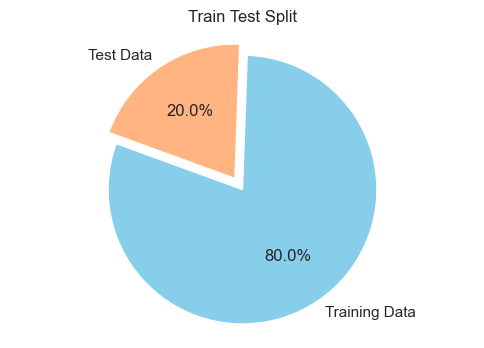

In [678]:
sizes  = [X_train_agg.shape[0], X_test_agg.shape[0]]
labels = ['Training Data', 'Test Data']
plt.figure(figsize=(6, 4))
plt.pie(sizes, explode=(0.1, 0), labels=labels, autopct='%1.1f%%',
        startangle=160, colors=['skyblue', sns.color_palette('pastel')[1]])
plt.title('Train Test Split')
plt.axis('equal')
plt.savefig('Test_Train_Split.png')
plt.show()

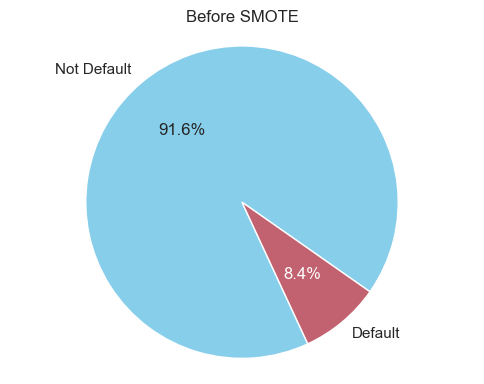

In [679]:
def plot_balance(y, title, filename):
    counts = y.value_counts()
    colors = ['skyblue', '#c26170']
    legend_labels = ['Not Default' if i == 0 else 'Default' for i in counts.index]
    plt.figure(figsize=(5, 4))
    _, _, autotexts = plt.pie(counts, labels=legend_labels, startangle=-35,
                               colors=colors, autopct='%1.1f%%')
    autotexts[1].set_color('white')
    plt.title(title)
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
 
plot_balance(Y_train, 'Before SMOTE', 'before_smote.png')

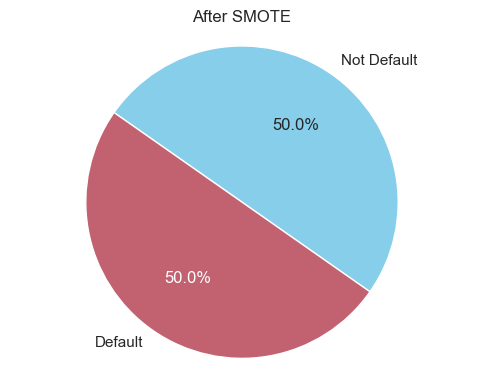

In [680]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(random_state=42)
X_train_res, Y_train_res = oversample.fit_resample(X_train_agg, Y_train)
plot_balance(pd.Series(Y_train_res), 'After SMOTE', 'after_smote.png')

In [681]:
from sklearn.tree import DecisionTreeClassifier
DT_classifier = DecisionTreeClassifier()

In [682]:
DT_classifier.fit(X_train_res, Y_train_res)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [685]:
Y_pred = DT_classifier.predict(X_test_agg)

In [686]:
# Training score
DT_classifier.score(X_train_res, Y_train_res)

0.9997744071552742

In [688]:
# Testing score
DT_classifier.score(X_test_agg, Y_test)

0.932225857057729

In [699]:
from sklearn.metrics import confusion_matrix, recall_score
print(confusion_matrix(Y_test, Y_pred))
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

[[73003  2354]
 [ 1628  5244]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     75357
           1       0.69      0.76      0.72      6872

    accuracy                           0.95     82229
   macro avg       0.83      0.87      0.85     82229
weighted avg       0.95      0.95      0.95     82229



In [690]:
#  Initialize the RF classifier
from sklearn.ensemble import RandomForestClassifier
RF_classifier = RandomForestClassifier(n_estimators = 300, max_samples = 0.75)

In [691]:
# Training the model
RF_classifier.fit(X_train_res, Y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [692]:
Y_pred = RF_classifier.predict(X_test_agg)

In [693]:
print(RF_classifier.score(X_train_res, Y_train_res))

0.9996566344201601


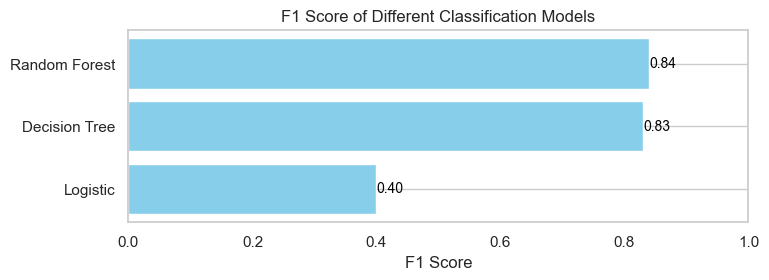

In [ ]:
models = ['Logistic', 'Decision Tree', 'Random Forest']
f1_scores = [0.85, 0.78, 0.82]  # Example F1 scores for each model

# Create horizontal bar plot
plt.figure(figsize=(8, 2.5))  # Adjusted the height
bars = plt.barh(models, f1_scores, color='skyblue')
plt.xlabel('F1 Score')
plt.title('F1 Score of Different Classification Models')
plt.xlim(0, 1)  # Limit the x-axis from 0 to 1
plt.grid(axis='x', alpha=0.7)  # Add grid lines

# Annotate bars with their respective values
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{score:.2f}',
             ha='left', va='center', fontsize=10, color='black')

# Remove vertical grid lines
plt.grid(axis='x', alpha=0)  # Remove vertical grid lines

# Save the plot to an image file
plt.savefig('classification_models_f1_scores.png', bbox_inches='tight')  # Save the plot as PNG

# Display the plot
plt.show()

In [695]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train_res)
X_test_std  = sc.transform(X_test_agg) 

In [696]:
from sklearn.linear_model import LogisticRegression
logistic_rgr = LogisticRegression(random_state=0, max_iter=1000)
logistic_rgr.fit(X_train_std, Y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [641]:
Y_pred = logistic_rgr.predict(X_test_std)

In [642]:
from sklearn.metrics import confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

Confusion Matrix:
[[62360 12997]
 [ 1580  5292]]


In [643]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, Y_pred)

0.8227267752252855

In [644]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.98      0.83      0.90     75357
           1       0.29      0.77      0.42      6872

    accuracy                           0.82     82229
   macro avg       0.63      0.80      0.66     82229
weighted avg       0.92      0.82      0.86     82229



In [663]:
from sklearn.linear_model import LogisticRegression
logistic_rgr = LogisticRegression(class_weight='balanced', random_state=0, max_iter=1000)
logistic_rgr.fit(X_train_std, Y_train_res)

Y_pred = logistic_rgr.predict(X_test_std)

In [664]:
from sklearn.metrics import confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

from sklearn.metrics import accuracy_score
accuracy_score(Y_test, Y_pred)

from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

Confusion Matrix:
[[62360 12997]
 [ 1580  5292]]
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     75357
           1       0.29      0.77      0.42      6872

    accuracy                           0.82     82229
   macro avg       0.63      0.80      0.66     82229
weighted avg       0.92      0.82      0.86     82229



In [665]:
logistic_rgr = LogisticRegression(class_weight='balanced', random_state=0)
logistic_rgr.fit(X_train_std, Y_train_res)
Y_prob = logistic_rgr.predict_proba(X_test_std)[:, 1]
Y_pred = (Y_prob >= 0.3).astype(int)

In [666]:
from sklearn.metrics import confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

from sklearn.metrics import accuracy_score
accuracy_score(Y_test, Y_pred)

from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

Confusion Matrix:
[[48753 26604]
 [  732  6140]]
              precision    recall  f1-score   support

           0       0.99      0.65      0.78     75357
           1       0.19      0.89      0.31      6872

    accuracy                           0.67     82229
   macro avg       0.59      0.77      0.55     82229
weighted avg       0.92      0.67      0.74     82229



Moving towards the model development phase

In [478]:
columns_list = ['grossapproval','initialinterestrate','fixedorvariableinterestind','businessage','terminmonths','terminyears','grosschargeoffamount',
                'jobssupported','sbaguranteedscore']
X = df.loc[:, df.columns.isin(columns_list)]

In [479]:
Y = df.iloc[:, -1]

In [480]:
X

,grossapproval,initialinterestrate,fixedorvariableinterestind,terminmonths,businessage,grosschargeoffamount,jobssupported,terminyears,sbaguranteedscore
0,10.563621,8.60,0,84,9,0.000000,2.833213,7.000000,0.934386
1,10.819798,6.25,1,84,9,0.000000,2.772589,7.000000,0.935939
2,9.210440,9.75,1,84,9,0.000000,1.098612,7.000000,0.924754
3,12.254868,6.00,1,31,9,11.223691,2.772589,2.583333,0.991403
4,8.517393,5.25,1,93,9,0.000000,1.386294,7.750000,0.918643
...,...,...,...,...,...,...,...,...,...
411140,12.014313,5.35,1,84,1,0.000000,1.098612,7.000000,0.976055
411141,11.512935,7.75,1,60,1,0.000000,3.526361,5.000000,0.975013
411142,11.254168,5.25,1,84,6,0.000000,2.833213,7.000000,0.990638
411143,10.714440,6.25,0,72,8,0.000000,1.098612,6.000000,0.935309


In [481]:
X.shape, Y.shape

((411145, 9), (411145,))

In [482]:
Y.value_counts()

loanstatus
0    376785
1     34360
Name: count, dtype: int64

In [507]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2,stratify=Y)

In [508]:
skew_cols = ['grossapproval', 'grosschargeoffamount', 'jobssupported']

for col in skew_cols:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])

In [509]:
# sizes = [X_train.shape[0], X_test.shape[0]]
# labels = ['Training Data', 'Test Data']
# explode = (0.1, 0)  # Explode the first slice (training data)

# # Plotting
# plt.figure(figsize=(6, 4))
# plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', startangle=160, colors=['skyblue', sns.color_palette('pastel')[1]])
# plt.title('Train Test Split')

# # Equal aspect ratio ensures that pie is drawn as a circle
# plt.axis('equal')

# # Save the figure before displaying it
# plt.savefig('Test_Train_Split.png')
# plt.show()

Visulization of target columns Before SMOTE 

In [510]:
# column_name = 'loanstatus'

# # Calculate value counts of the column
# column_counts = Y_train.value_counts()

# # Defining colors for each category
# colors = ['skyblue', '#c26170']

# # Define labels for the legend
# legend_labels = ['Not Default' if idx == 0 else 'Default' for idx in column_counts.index]

# # Plotting 
# plt.figure(figsize=(5, 4))
# patches, texts, autotexts = plt.pie(column_counts, labels=legend_labels, startangle=-35, colors=colors, autopct='%1.1f%%')
# plt.title('Before SMOTE')
# plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
# sns.set(style='whitegrid')  # apply seaborn style

# # Set color for the percentage text
# autotexts[1].set_color('white')  # 1 corresponds to the percentage text of the second slice

# plt.tight_layout()
# plt.savefig('before_smote.png')  # Save the figure before displaying it
# plt.show()

In [511]:
# from imblearn.over_sampling import SMOTE
# oversample = SMOTE()
# X_train, Y_train = oversample.fit_resample(X_train, Y_train)

visualization of data after split

In [512]:
# column_name = 'loanstatus'

# # Calculate value counts of the column
# column_counts = Y_train.value_counts()

# # Defining colors for each category
# colors = ['skyblue', '#c26170']

# # Define labels for the legend
# legend_labels = ['Not Default' if idx == 0 else 'Default' for idx in column_counts.index]

# # Plotting 
# plt.figure(figsize=(5, 4))
# patches, texts, autotexts = plt.pie(column_counts, labels=legend_labels, startangle=-35, colors=colors, autopct='%1.1f%%')
# plt.title('After SMOTE')
# plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
# sns.set(style='whitegrid')  # apply seaborn style

# # Set color for the percentage text
# autotexts[1].set_color('white')  # 1 corresponds to the percentage text of the second slice

# plt.tight_layout()
# plt.savefig('after_smote.png')  # Save the figure before displaying it
# plt.show()

In [513]:
# X.shape,Y.shape

Using Logistic Regression to predict the target variable loanstatus

Standardizing the columns because the Logistic regression model internally uses distance metric. Gradient Descent uses the euclidean distance. So if we have the data in different standards/units/scales(eg: Salary in lakhs, experience in 10-50), then the model will not be perfect.

In [523]:
if 'grosschargeoffamount' in columns_list:
    columns_list.remove('grosschargeoffamount')

In [524]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [525]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=2)
X_train_res, Y_train_res = sm.fit_resample(X_train_std, Y_train)

print("After SMOTE:", X_train_res.shape)

After SMOTE: (602856, 9)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=0)
model.fit(X_train_res, Y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [ ]:
# logistic_rgr.fit(X_train_std, Y_train)

In [ ]:
Y_pred = model.predict(X_test_std)

In [519]:
# pd.DataFrame(data = {'Predicted Labels': Y_pred, 'Actual Labels': Y_test})

In [528]:
df['grosschargeoffamount'].value_counts()

grosschargeoffamount
0.000000     376798
10.126671       293
10.819798       152
11.512935       113
9.210440        102
              ...  
10.122982         1
9.649510          1
12.802096         1
9.737421          1
10.120434         1
Name: count, Length: 32950, dtype: int64

In [529]:
(df['grosschargeoffamount'] > 0).astype(int).equals(df['loanstatus'])

False

In [530]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test, Y_pred))

[[75357     0]
 [    4  6868]]


In [495]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, Y_pred)

0.9999391942015591

In [496]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     75498
           1       1.00      1.00      1.00      6731

    accuracy                           1.00     82229
   macro avg       1.00      1.00      1.00     82229
weighted avg       1.00      1.00      1.00     82229



In [497]:
leaky_cols = [
    'totaldefaultcounts',
    'totalpctdefault',
    'yearlydefaultcounts',
    'cumulativedefault'
]
columns_list = [col for col in columns_list if col not in leaky_cols]

In [498]:
from sklearn.tree import DecisionTreeClassifier
DT_classifier = DecisionTreeClassifier()

In [499]:
DT_classifier.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [500]:
Y_pred = DT_classifier.predict(X_test)

In [501]:
DT_classifier.feature_importances_

array([1.27249091e-05, 1.45477564e-05, 0.00000000e+00, 2.49831727e-08,
       6.61653201e-06, 9.99905963e-01, 4.58253858e-06, 1.40661298e-05,
       4.14737226e-05])

In [502]:
DT_classifier.score(X_train, Y_train)

0.9999983404527909

In [503]:
DT_classifier.score(X_test, Y_test)

0.9998905495628063

In [504]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, Y_pred)

0.9998905495628063

In [505]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test, Y_pred))

[[75494     4]
 [    5  6726]]


In [506]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     75498
           1       1.00      1.00      1.00      6731

    accuracy                           1.00     82229
   macro avg       1.00      1.00      1.00     82229
weighted avg       1.00      1.00      1.00     82229

